# Customer Shopping Trends — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_PATH = r'Dataset/Customer Shopping Trends/shopping_trends_project.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 1. Schema & Data Types

In [2]:
df.dtypes.to_frame('dtype')

,dtype
Customer ID,int64
Age,int64
Gender,str
Item Purchased,str
Category,str
Purchase Amount (USD),int64
Location,str
Size,str
Color,str
Season,str


## 2. Missing Values

In [3]:
missing = df.isnull().sum().to_frame('missing')
missing['pct'] = (missing['missing'] / len(df) * 100).round(2)
missing[missing['missing'] > 0]

,missing,pct


## 3. Summary Statistics

In [4]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


## 4. Categorical Column Value Counts

In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'\n--- {col} ({df[col].nunique()} unique) ---')
    print(df[col].value_counts().to_string())


--- Gender (2 unique) ---
Gender
Male      2652
Female    1248

--- Item Purchased (25 unique) ---
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124

--- Category (4 unique) ---
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324

--- Location (50 unique) ---
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont           85
Louisiana         84
North

C:\Users\mizzo\AppData\Local\Temp\ipykernel_33168\2841377485.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 5. Numeric Distributions

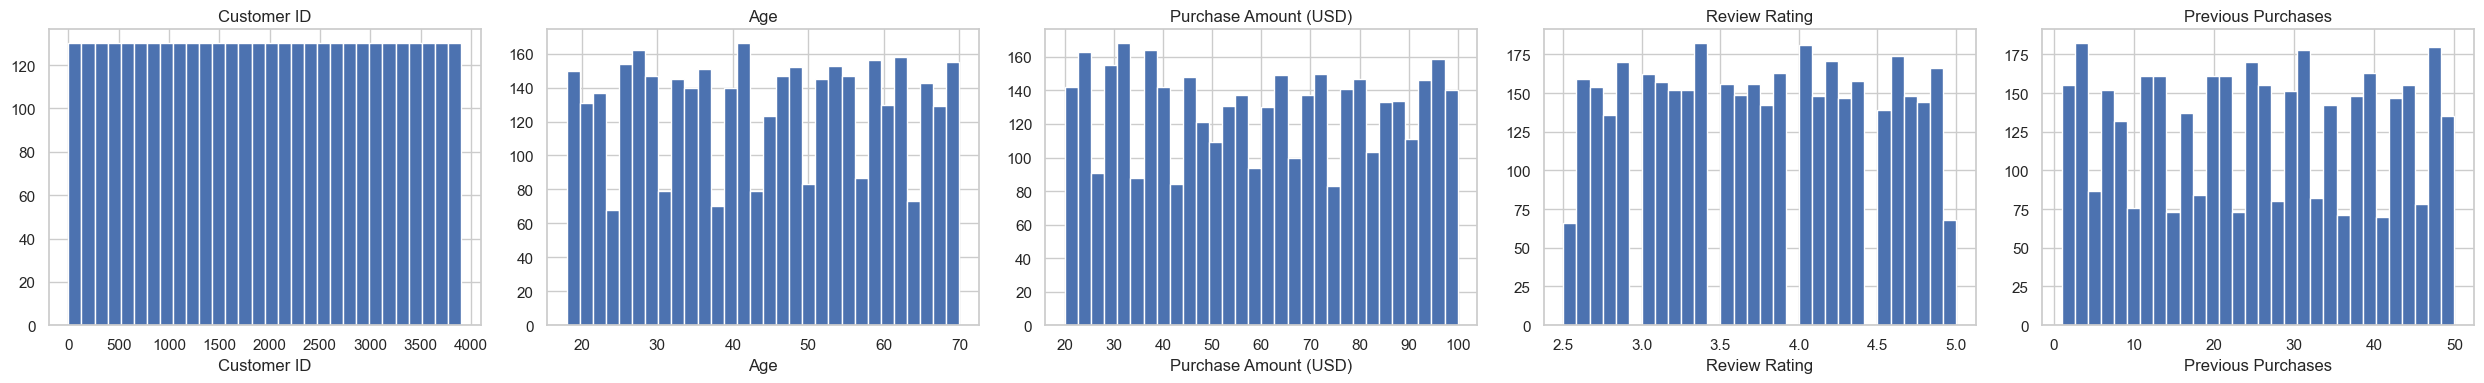

In [6]:
num_cols = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    df[col].hist(bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

## 6. Purchase Amount by Category

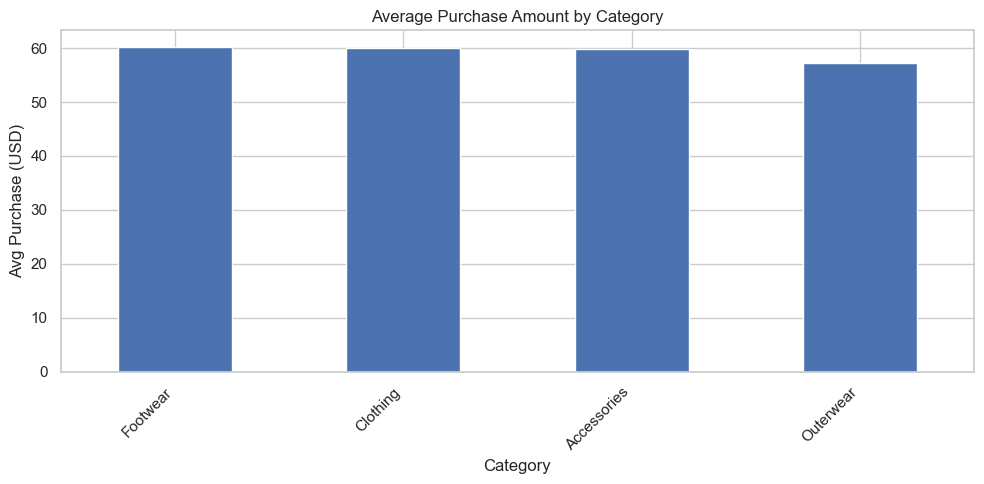

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False).plot(kind='bar', ax=ax)
ax.set_title('Average Purchase Amount by Category')
ax.set_ylabel('Avg Purchase (USD)')
ax.set_xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Shipping Type Distribution

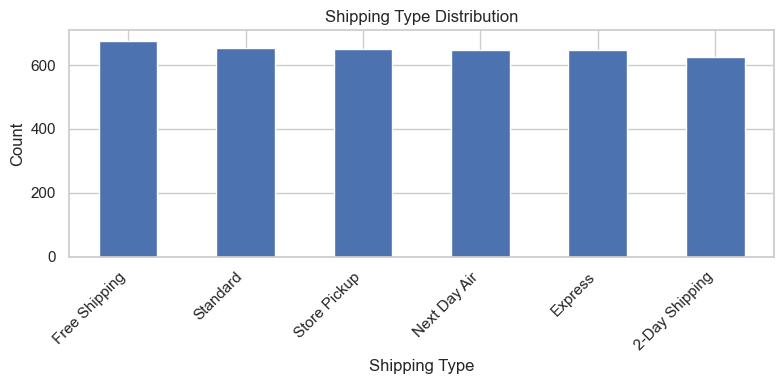

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df['Shipping Type'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Shipping Type Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Shipping Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Purchase Amount by Shipping Type

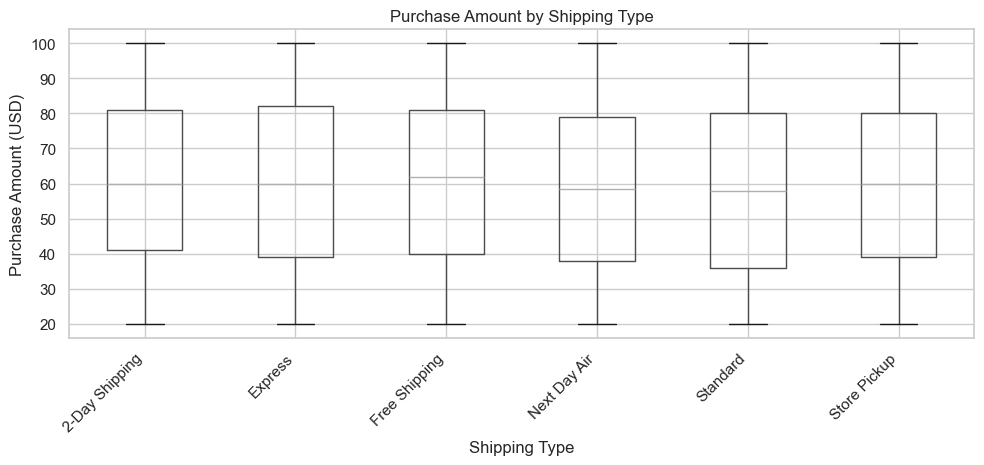

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='Purchase Amount (USD)', by='Shipping Type', ax=ax)
ax.set_title('Purchase Amount by Shipping Type')
ax.set_xlabel('Shipping Type')
ax.set_ylabel('Purchase Amount (USD)')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Review Rating Distribution

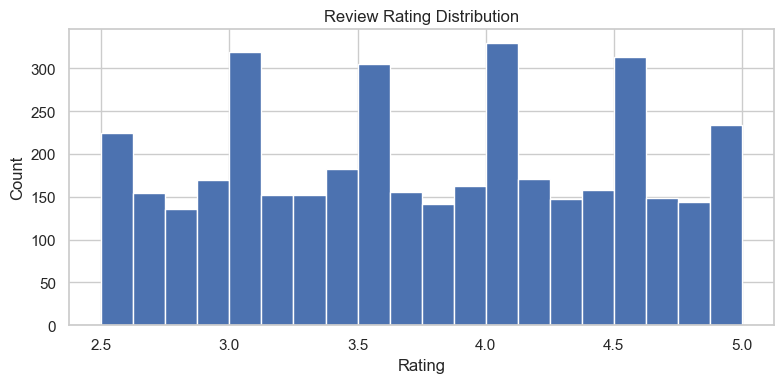

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
df['Review Rating'].hist(bins=20, ax=ax)
ax.set_title('Review Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 10. Top 10 Locations by Order Volume

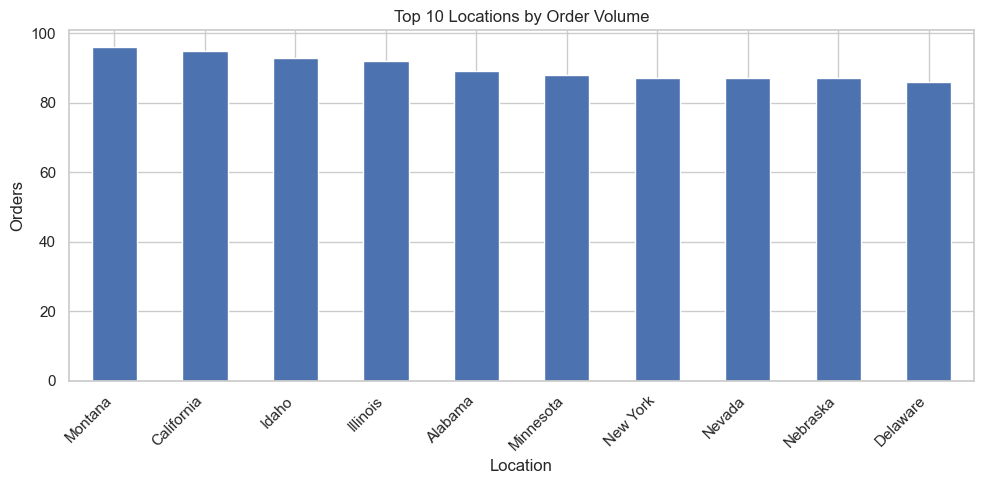

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df['Location'].value_counts().head(10).plot(kind='bar', ax=ax)
ax.set_title('Top 10 Locations by Order Volume')
ax.set_ylabel('Orders')
ax.set_xlabel('Location')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Correlation Heatmap (Numeric Columns)

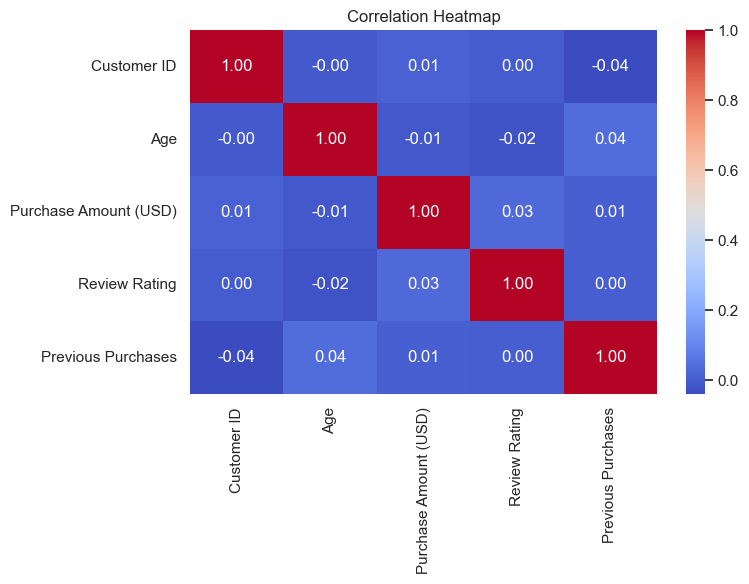

In [12]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 12. EDA Notes
*(Add observations here as you explore the data)*
- 
